# Task 3: Helper notebook for loading the data and saving the predictions

In [1]:
import pickle
import gzip
import numpy as np
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_otsu, threshold_yen, threshold_multiotsu
from skimage.feature import canny



import os

### Helper functions

In [2]:
def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object

In [3]:
def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

### Load data, make predictions and save prediction in correct format

In [4]:
# load data
train_data_loaded = load_zipped_pickle("train.pkl")
test_data = load_zipped_pickle("test.pkl")
#samples = load_zipped_pickle("sample.pkl")


In [5]:
#As the data is really small, we repeat it to have more samples for the batches in ImageDataGenerator
expert_train_data = []
for i in train_data_loaded:
    if i['dataset'] == 'expert':
        expert_train_data.append(i)
expert_train_data = np.array(expert_train_data)
expert_train_data = np.repeat(expert_train_data, 10, axis=0)
train_data = np.repeat(train_data_loaded, 6, axis=0)
train_data = np.concatenate((train_data, expert_train_data), axis=0)
print(train_data.shape)
# test_data = np.repeat(test_data, 5, axis=0)

(580,)


In [5]:
# puts images in the right shape
def reshape_data(data, x, y):
    return cv2.resize(data, dsize=(x, y), interpolation=cv2.INTER_CUBIC)

In [6]:
# add different channels

# denoise channel
def denoise(data):
    return denoise_nl_means(data, h=0.8 * estimate_sigma(data), fast_mode=True, patch_size=5, patch_distance=6)

# blur channel
def blur(data, mode="median"):
    if mode == "median":
        return cv2.medianBlur(data, 3)
    elif mode == "gauss":
        return cv2.GaussianBlur(data, (3,3), 1)

# threshold channel
def myThreshold(data, method='otsu', class_nb = 0):
    if method == 'otsu':
        thresh_val = threshold_otsu(data)
        mask = (data > thresh_val).astype(np.float32)
    elif method == 'yen':
        thresh_val = threshold_yen(data)
        mask = (data > thresh_val).astype(np.float32)
    elif method == 'multiotsu':
        # 3 classes
        thresholds = threshold_multiotsu(data, classes=3)
        mask = np.digitize(data, bins=thresholds)
        mask = (mask == class_nb).astype(np.float32)
    return mask


# edge detection channel
def edge(data, sigma=1.0):
    edges = canny(data, sigma=sigma).astype(np.float32)
    return edges


def preprocess_images(images, labels,
                      add_denoised=True, 
                      add_blurred=True, 
                      blur_mode='median', 
                      add_threshold=True, 
                      threshold_method='otsu',
                      class_nb=0,
                      add_edges=True):

    images = np.asarray(images, dtype=np.float32)

    channels = [images]  # original images are one channel then add others
    stacked_labels = [labels]

    if add_denoised:
        denoised_imgs = np.stack([denoise(img) for img in images], axis=0)
        channels.append(denoised_imgs)
        stacked_labels.append(labels)

    if add_blurred:
        blurred_imgs = np.stack([blur(img, mode=blur_mode) for img in images], axis=0)
        channels.append(blurred_imgs)
        stacked_labels.append(labels)


    if add_threshold:
        threshold_imgs = np.stack([myThreshold(img, method=threshold_method, class_nb=class_nb) for img in images], axis=0)
        channels.append(threshold_imgs)
        stacked_labels.append(labels)

    if add_edges:
        edge_imgs = np.stack([edge(img) for img in images], axis=0)
        channels.append(edge_imgs)
        stacked_labels.append(labels)

    combined = np.stack(channels, axis=-1)
    stacked_labels = np.stack(stacked_labels, axis=-1)

    return combined, stacked_labels

In [7]:
from tqdm import tqdm
import matplotlib.pyplot as plt
image_size = 512

def preprocess_train_data(data):
    video_frames = []
    mask_frames = []
    names = []
    boxes = []
    for item in tqdm(data):
        video = item['video']
        name = item['name']
        box = item['box']
        height, width, n_frames = video.shape
        mask = np.zeros((height, width, n_frames), dtype=np.bool)
        for frame in item['frames']:
            mask[:, :, frame] = item['label'][:, :, frame]
            video_frame = video[:, :, frame].astype(np.float32) / 255.0 #we scale down images
            video_frame = reshape_data(video_frame, image_size, image_size)
            mask_frame = mask[:, :, frame].astype(np.uint8)
            mask_frame = reshape_data(mask_frame, image_size, image_size)

            #video_frame = np.expand_dims(video_frame, axis=0) #put in the format (1, image_size, image_size)

            #mask_frame = np.expand_dims(mask_frame, axis=0)
            
            video_frames.append(video_frame)
            mask_frames.append(mask_frame)
            #They both appear 3 times in total (3 frames), to get the same size of all lists
            names.append(name)
            boxes.append(box)


    boxes = [np.array(box).astype(np.uint8) for box in boxes]
    return names, video_frames, mask_frames, boxes

In [9]:
names, videos, masks, boxes = preprocess_train_data(train_data)
videos, masks = preprocess_images(videos, masks, add_denoised=True, add_blurred=True, blur_mode='median', add_threshold=True, threshold_method='otsu', class_nb=0, add_edges=True)
#test_names, test_videos = preprocess_test_data(test_data)

# IMPORTANTTTT
# might want to add different channels for the videos, e.g. optical flow, or blurred/denoised images
# and so need to stack the masks as many times as the number of channels
print(videos[0].shape, masks[0].shape, len(boxes))

  0%|          | 0/580 [00:00<?, ?it/s]C:\Users\tzamb\AppData\Local\Temp\ipykernel_1288\980307570.py:15: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros((height, width, n_frames), dtype=np.bool)
100%|██████████| 580/580 [00:24<00:00, 23.24it/s] 


(64, 64, 5) (64, 64, 5) 1740


In [10]:
seed = 42
batch_size = 8  #hyperparameter to optimise


#We do data augmentation, to facilitate our life we use the ImageDataGenerator from Keras
datagen_video = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='constant')
#We dont flip because the right mitral valve is going to be on the right and don't want to confuse model
#Might want to check the hyperparameters of the ImageDataGenerator

datagen_mask = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='constant')


#X is videos, Y is masks (labels)
def generate_data(X_train, y_train, X_valid, y_valid, batch_size):
    generated_X_train = datagen_video.flow(X_train, batch_size=batch_size, seed=seed)
    generated_y_train = datagen_mask.flow(y_train, batch_size=batch_size, seed=seed)
    generated_X_valid = datagen_video.flow(X_valid, batch_size=batch_size, seed=seed)
    generated_y_valid = datagen_mask.flow(y_valid, batch_size=batch_size, seed=seed)
    
    # we create "tuples" of the videos and masks
    def zip_generated_data(generated_X, generated_y):
        for X, y in zip(generated_X, generated_y):
            yield (X, y)
    
    generated_data_train = zip_generated_data(generated_X_train, generated_y_train)
    generated_data_valid = zip_generated_data(generated_X_valid, generated_y_valid)

    return generated_data_train, generated_data_valid


def generate_data_full(X_train, y_train, batch_size):
    generated_X_train = datagen_video.flow(X_train, batch_size=batch_size, seed=seed)
    generated_y_train = datagen_mask.flow(y_train, batch_size=batch_size, seed=seed)
    
    # we create "tuples" of the videos and masks
    def zip_generated_data(generated_X, generated_y):
        for X, y in zip(generated_X, generated_y):
            yield (X, y)
    
    generated_data_train = zip_generated_data(generated_X_train, generated_y_train)

    return generated_data_train


In [11]:
#We split the data into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(videos, masks, test_size=0.2, random_state=42)
print(X_train.shape)
print(len(X_train), len(X_valid), len(y_train), len(y_valid))

# To train with full dataset
# X_train = videos
# y_train = masks

(1392, 64, 64, 5)
1392 348 1392 348


In [12]:
# #We generate the data
generated_data_train, generated_data_valid = generate_data(X_train, y_train, X_valid, y_valid, batch_size=batch_size)
print(generated_data_train.__next__()[0][0].shape)

# To train with full data
# generated_data_train = generate_data_full(X_train, y_train, batch_size=batch_size)
# print(generated_data_train.__next__()[0][0].shape)

(64, 64, 5)


C:\Users\tzamb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\keras\preprocessing\image.py:766: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (1392, 64, 64, 5) (5 channels).
  warnings.warn(
C:\Users\tzamb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\keras\preprocessing\image.py:766: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (348, 64, 64, 5) (5 channels).
  warnings.warn(


In [13]:
# num_channels = img.shape[-1]

# plt.figure(figsize=(15, 3))  # Adjust figure size as needed
# for i in range(num_channels):
#     plt.subplot(1, num_channels, i + 1)
#     plt.imshow(img[:,:,i], cmap='gray')
#     plt.title(f'Channel {i}')
#     plt.axis('off')

# plt.tight_layout()
# plt.show()

In [14]:
#Now need to develope the model


In [21]:
import segmentation_models_pytorch as smp
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn, optim


In [8]:
def combined_bce_dice_loss(preds, targets, alpha=0.5, beta=0.5, eps=1e-6):
    bce = torch.nn.functional.binary_cross_entropy(preds, targets)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    dice = 1 - (2.0 * intersection + eps) / (union + eps)
    return alpha * bce + beta * dice

# Training function
def train_model(model, train_generator, valid_generator, steps_per_epoch, validation_steps, num_epochs=10, path_to_best_model="best_model"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    best_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        # Limit the training generator to steps_per_epoch batches
        for step in range(steps_per_epoch):
            videos, masks = next(train_generator)  # Get the next batch
            videos = torch.tensor(videos).permute(0, 3, 1, 2).to(device)
            masks = torch.tensor(masks).unsqueeze(1).to(device)
            masks = masks[..., 0]

            optimizer.zero_grad()
            outputs = model(videos)
            outputs = torch.sigmoid(outputs)
            loss = combined_bce_dice_loss(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * videos.shape[0]

        train_loss /= steps_per_epoch * videos.shape[0]

        model.eval()
        valid_loss = 0.0

        # Limit the validation generator to validation_steps batches
        with torch.no_grad():
            for step in range(validation_steps):
                videos, masks = next(valid_generator)
                videos = torch.tensor(videos).permute(0, 3, 1, 2).to(device)
                masks = torch.tensor(masks).unsqueeze(1).to(device)
                masks = masks[..., 0]

                outputs = model(videos)
                outputs = torch.sigmoid(outputs)
                loss = combined_bce_dice_loss(outputs, masks)

                valid_loss += loss.item() * videos.shape[0]

        valid_loss /= validation_steps * videos.shape[0]

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
        
        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), path_to_best_model)

    return model


In [9]:
def combined_bce_dice_loss(preds, targets, alpha=0.5, beta=0.5, eps=1e-6):
    bce = torch.nn.functional.binary_cross_entropy(preds, targets)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    dice = 1 - (2.0 * intersection + eps) / (union + eps)
    return alpha * bce + beta * dice


def train_model_full(model, train_generator, steps_per_epoch, num_epochs=10, path_to_best_model="best_model"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    best_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        # Limit the training generator to steps_per_epoch batches
        for step in range(steps_per_epoch):
            videos, masks = next(train_generator)  # Get the next batch
            videos = torch.tensor(videos).permute(0, 3, 1, 2).to(device)
            masks = torch.tensor(masks).unsqueeze(1).to(device)
            masks = masks[..., 0]

            optimizer.zero_grad()
            outputs = model(videos)
            outputs = torch.sigmoid(outputs)
            loss = combined_bce_dice_loss(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * videos.shape[0]

        train_loss /= steps_per_epoch * videos.shape[0]

        model.eval()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}")
        # We use train loss instead of valid
        if train_loss < best_loss:
            best_loss = train_loss
            torch.save(model.state_dict(), path_to_best_model)

    return model

In [10]:
class SegmentationModel(nn.Module):
      def __init__(self, in_channels, out_channels):
        super(SegmentationModel,self).__init__()

        self.backbone = smp.Unet(
            encoder_name = 'timm-efficientnet-b8',
            encoder_weights = 'imagenet',
            # encoder_weights = None,
            in_channels = in_channels,
            classes = out_channels,
            activation = None
        )

      def forward(self, images):
        return self.backbone(images)

In [22]:
class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels, out_channels):  # Fix the typo here
        super(UNetPlusPlus, self).__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name="resnet34",  # Choose a ResNet backbone
            encoder_weights="imagenet",  # Pre-trained on ImageNet
            in_channels=in_channels,
            classes=out_channels
        )

    def forward(self, x):
        return self.model(x)
    



In [23]:
class DeepLabV3Plus(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DeepLabV3Plus, self).__init__()
        self.model = smp.DeepLabV3Plus(
            encoder_name="resnet50",  # Change backbone if needed
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels
        )

    def forward(self, x):
        return self.model(x)

In [24]:
class AttentionUNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(AttentionUNet, self).__init__()
        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            decoder_attention_type="scse"  # Spatial and Channel Squeeze & Excitation
        )

    def forward(self, x):
        return self.model(x)

In [25]:
class FPN(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(FPN, self).__init__()
        self.model = smp.FPN(
            encoder_name="resnet50",  # Use different backbones
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels
        )

    def forward(self, x):
        return self.model(x)

In [15]:
# SHITTY MODEL


# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class UNet3Plus(nn.Module):
#     def __init__(self, in_channels=5, out_channels=1, base_channels=64):
#         super(UNet3Plus, self).__init__()
#         self.in_channels = in_channels
#         self.out_channels = out_channels

#         # Encoder
#         self.encoder1 = self.conv_block(in_channels, base_channels)          # 256x256
#         self.encoder2 = self.conv_block(base_channels, base_channels * 2)    # 128x128
#         self.encoder3 = self.conv_block(base_channels * 2, base_channels * 4) # 64x64
#         self.encoder4 = self.conv_block(base_channels * 4, base_channels * 8) # 32x32

#         # Bottleneck
#         self.bottleneck = self.conv_block(base_channels * 8, base_channels * 16) # 16x16

#         # Decoder
#         self.up4 = self.upconv(base_channels * 16, base_channels * 8)  # Upsample to 32x32
#         self.decoder4 = self.conv_block(base_channels * 16, base_channels * 8)

#         self.up3 = self.upconv(base_channels * 8, base_channels * 4)   # Upsample to 64x64
#         self.decoder3 = self.conv_block(base_channels * 8, base_channels * 4)

#         self.up2 = self.upconv(base_channels * 4, base_channels * 2)   # Upsample to 128x128
#         self.decoder2 = self.conv_block(base_channels * 4, base_channels * 2)

#         self.up1 = self.upconv(base_channels * 2, base_channels)       # Upsample to 256x256
#         self.decoder1 = self.conv_block(base_channels * 2, base_channels)

#         # Final convolution
#         self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

#         # Max pooling
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#     def conv_block(self, in_channels, out_channels):
#         return nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True)
#         )

#     def upconv(self, in_channels, out_channels):
#         return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

#     def forward(self, x):
#         # Encoder
#         enc1 = self.encoder1(x)        # 256x256
#         enc2 = self.encoder2(self.pool(enc1))  # 128x128
#         enc3 = self.encoder3(self.pool(enc2))  # 64x64
#         enc4 = self.encoder4(self.pool(enc3))  # 32x32

#         # Bottleneck
#         bottleneck = self.bottleneck(self.pool(enc4))  # 16x16

#         # Decoder
#         dec4 = self.up4(bottleneck)              # 32x32
#         dec4 = torch.cat([dec4, enc4], dim=1)
#         dec4 = self.decoder4(dec4)

#         dec3 = self.up3(dec4)                    # 64x64
#         dec3 = torch.cat([dec3, enc3], dim=1)
#         dec3 = self.decoder3(dec3)

#         dec2 = self.up2(dec3)                    # 128x128
#         dec2 = torch.cat([dec2, enc2], dim=1)
#         dec2 = self.decoder2(dec2)

#         dec1 = self.up1(dec2)                    # 256x256
#         dec1 = torch.cat([dec1, enc1], dim=1)
#         dec1 = self.decoder1(dec1)

#         # Final output
#         out = self.final_conv(dec1)
#         return out


In [16]:
# SHITTY MODEL

# import segmentation_models_pytorch as smp
# import torch
# import torch.nn as nn

# class HRNet(nn.Module):
#     def __init__(self, in_channels=5, out_channels=1):
#         super(HRNet, self).__init__()
#         self.model = smp.DeepLabV3Plus(
#             encoder_name="resnet101",  # HRNet encoder
#             encoder_weights="imagenet",  # Use pre-trained weights
#             in_channels=in_channels,
#             classes=out_channels,
#         )

#     def forward(self, x):
#         return self.model(x)

In [26]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn

class EfficientNetUNetPlusPlus(nn.Module):
    def __init__(self, in_channels, out_channels, encoder_name="efficientnet-b4"):

        super(EfficientNetUNetPlusPlus, self).__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name=encoder_name, 
            encoder_weights="imagenet", 
            in_channels=in_channels, 
            classes=out_channels
        )

    def forward(self, x):
        return self.model(x)

In [18]:
# from transformers import SegformerForSemanticSegmentation
# import torch

# class SegFormerModel:
#     def __init__(self, model_name="nvidia/segformer-b0-finetuned-ade-512-512"):
#         """
#         Initializes the SegFormer model.
#         :param model_name: Name of the SegFormer model (e.g., "nvidia/segformer-b0-finetuned-ade-512-512").
#         """
#         self.model = SegformerForSemanticSegmentation.from_pretrained(model_name)
    
#     def predict(self, images):
#         """
#         Predicts segmentation maps for the input images.
#         :param images: Tensor of shape (B, C, H, W).
#         :return: Predicted segmentation maps.
#         """
#         with torch.no_grad():
#             outputs = self.model(pixel_values=images)
#         return outputs.logits.argmax(dim=1)  # Outputs the segmentation map


# need to be 512x512

In [19]:
# SHITTY MODEL


# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class ResBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super(ResBlock, self).__init__()
#         self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(out_channels)
#         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(out_channels)
#         self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)

#     def forward(self, x):
#         residual = self.shortcut(x)
#         out = F.relu(self.bn1(self.conv1(x)))
#         out = self.bn2(self.conv2(out))
#         out += residual
#         return F.relu(out)


# class ResUNet(nn.Module):
#     def __init__(self, in_channels=5, out_channels=1, features=[64, 128, 256, 512]):
#         super(ResUNet, self).__init__()
#         self.encoder1 = ResBlock(in_channels, features[0])
#         self.encoder2 = ResBlock(features[0], features[1])
#         self.encoder3 = ResBlock(features[1], features[2])
#         self.encoder4 = ResBlock(features[2], features[3])

#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#         self.bottleneck = ResBlock(features[3], features[3] * 2)

#         self.up4 = nn.ConvTranspose2d(features[3] * 2, features[3], kernel_size=2, stride=2)
#         self.decoder4 = ResBlock(features[3] * 2, features[3])

#         self.up3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
#         self.decoder3 = ResBlock(features[2] * 2, features[2])

#         self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
#         self.decoder2 = ResBlock(features[1] * 2, features[1])

#         self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
#         self.decoder1 = ResBlock(features[0] * 2, features[0])

#         self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

#     def forward(self, x):
#         enc1 = self.encoder1(x)  # 256x256
#         enc2 = self.encoder2(self.pool(enc1))  # 128x128
#         enc3 = self.encoder3(self.pool(enc2))  # 64x64
#         enc4 = self.encoder4(self.pool(enc3))  # 32x32

#         bottleneck = self.bottleneck(self.pool(enc4))  # 16x16

#         dec4 = self.up4(bottleneck)
#         dec4 = torch.cat([F.interpolate(enc4, size=dec4.shape[2:], mode="bilinear"), dec4], dim=1)
#         dec4 = self.decoder4(dec4)

#         dec3 = self.up3(dec4)
#         dec3 = torch.cat([F.interpolate(enc3, size=dec3.shape[2:], mode="bilinear"), dec3], dim=1)
#         dec3 = self.decoder3(dec3)

#         dec2 = self.up2(dec3)
#         dec2 = torch.cat([F.interpolate(enc2, size=dec2.shape[2:], mode="bilinear"), dec2], dim=1)
#         dec2 = self.decoder2(dec2)

#         dec1 = self.up1(dec2)
#         dec1 = torch.cat([F.interpolate(enc1, size=dec1.shape[2:], mode="bilinear"), dec1], dim=1)
#         dec1 = self.decoder1(dec1)

#         return torch.sigmoid(self.final_conv(dec1))





In [27]:
# Example usage:
model = UNetPlusPlus(in_channels=5, out_channels=1)
steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size

trained_model = train_model(
    model,
    train_generator=generated_data_train,
    valid_generator=generated_data_valid,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    num_epochs=1,
    path_to_best_model="best_model_uNetPP_test.pth"
)

cuda
Epoch 1/1, Train Loss: 0.6936, Valid Loss: 0.5940


In [28]:
model = DeepLabV3Plus(in_channels=5, out_channels=1)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size

trained_model = train_model(
    model,
    train_generator=generated_data_train,
    valid_generator=generated_data_valid,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    num_epochs=1,
    path_to_best_model="model_test_dlv3p_test.pth"
)

cuda
Epoch 1/1, Train Loss: 0.6580, Valid Loss: 0.5823


In [29]:
model = FPN(in_channels=5, out_channels=1)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size

trained_model = train_model(
    model,
    train_generator=generated_data_train,
    valid_generator=generated_data_valid,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    num_epochs=1,
    path_to_best_model="best_model_fpn_test.pth"
)

cuda
Epoch 1/1, Train Loss: 0.4849, Valid Loss: 0.4037


In [30]:
model = EfficientNetUNetPlusPlus(in_channels=5, out_channels=1)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size

trained_model = train_model(
    model,
    train_generator=generated_data_train,
    valid_generator=generated_data_valid,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    num_epochs=1,
    path_to_best_model="best_model_effNetPP_test.pth"
)

cuda
Epoch 1/1, Train Loss: 0.6904, Valid Loss: 0.6108


In [31]:
model = AttentionUNet(in_channels=5, out_channels=1)

steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size

trained_model = train_model(
    model,
    train_generator=generated_data_train,
    valid_generator=generated_data_valid,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    num_epochs=1,
    path_to_best_model="best_model_attUNet_test.pth"
)

cuda
Epoch 1/1, Train Loss: 0.7360, Valid Loss: 0.6312


In [32]:
# x_valid_sample, y_valid_sample = next(generated_data_valid)  # Get one batch from the generator


1034


C:\Users\tzamb\AppData\Local\Temp\ipykernel_10040\1725363635.py:41: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(5, num_samples_to_plot, num_samples_to_plot + i + 1)
C:\Users\tzamb\AppData\Local\Temp\ipykernel_10040\1725363635.py:58: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


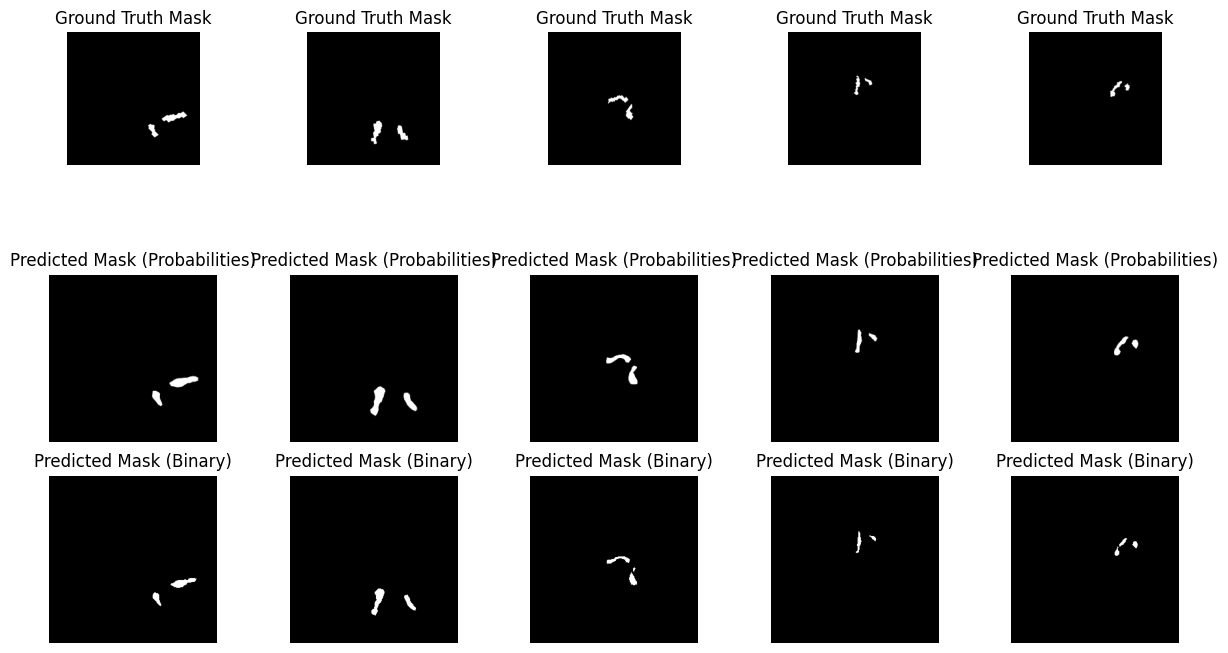

In [39]:
# import numpy as np
# import torch
# import matplotlib.pyplot as plt

# # Generate predictions on the validation data

# # Convert validation images to a PyTorch tensor
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# x_valid_sample_tensor = torch.tensor(x_valid_sample).permute(0, 3, 1, 2).to(device)  # (B, C, H, W)

# # Move the model to evaluation mode
# trained_model.eval()

# # Predict masks
# with torch.no_grad():
#     predicted_masks = trained_model(x_valid_sample_tensor)
#     predicted_masks = torch.sigmoid(predicted_masks).cpu().numpy()  # Convert to NumPy (Probabilities)
#     print(len(predicted_masks[predicted_masks>0.9999999]))


# # Apply thresholding
# threshold = 0.999
# binary_predicted_masks = (predicted_masks > threshold).astype(np.uint8)  # Convert to binary

# # Remove channel dimension (if present) for visualization
# predicted_masks = np.squeeze(predicted_masks, axis=1) if predicted_masks.shape[1] == 1 else predicted_masks
# binary_predicted_masks = np.squeeze(binary_predicted_masks, axis=1) if binary_predicted_masks.shape[1] == 1 else binary_predicted_masks
# y_valid_sample = np.squeeze(y_valid_sample, axis=-1) if y_valid_sample.shape[-1] == 1 else y_valid_sample
# # Visualize a few examples
# num_samples_to_plot = min(5, x_valid_sample.shape[0])  # Plot up to 5 samples
# plt.figure(figsize=(15, 10))

# for i in range(num_samples_to_plot):
#     # Plot the original image (first channel assumed as grayscale)
#     plt.subplot(4, num_samples_to_plot, i + 1)
#     plt.imshow(x_valid_sample[i, :, :, 0], cmap="gray")
#     plt.title("Original Image")
#     plt.axis("off")
    
#     # Plot the ground truth mask
#     plt.subplot(5, num_samples_to_plot, num_samples_to_plot + i + 1)
#     plt.imshow(y_valid_sample[i][..., 0], cmap="gray")  # Plot ground truth mask
#     plt.title("Ground Truth Mask")
#     plt.axis("off")
    
#     # Plot the predicted mask (probabilities)
#     plt.subplot(4, num_samples_to_plot, 2 * num_samples_to_plot + i + 1)
#     plt.imshow(predicted_masks[i], cmap="gray")
#     plt.title("Predicted Mask (Probabilities)")
#     plt.axis("off")
    
#     # Plot the binary predicted mask (after thresholding)
#     plt.subplot(4, num_samples_to_plot, 3 * num_samples_to_plot + i + 1)
#     plt.imshow(binary_predicted_masks[i], cmap="gray")
#     plt.title("Predicted Mask (Binary)")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


In [8]:
def preprocess_test_data(data):
    video_frames = []
    names = []
    for item in tqdm(data):
        video = item['video']
        video = video.astype(np.float32).transpose((2, 0, 1))
        video = np.expand_dims(video, axis=3)
        video_frames += list(video)
        names += [item['name'] for _ in video]
    return names, video_frames

In [9]:
def preprocess_test(images,
                      add_denoised=True, 
                      add_blurred=True, 
                      blur_mode='median', 
                      add_threshold=True, 
                      threshold_method='otsu',
                      class_nb=0,
                      add_edges=True,
                      duplicate=False):
    
    images = np.asarray(images, dtype=np.float32)

    channels = [images]  # original images are one channel then add others
    if add_denoised:
        denoised_imgs = np.stack([denoise(img) for img in images], axis=0)
        channels.append(denoised_imgs)

    if add_blurred:
        blurred_imgs = np.stack([blur(img, mode=blur_mode) for img in images], axis=0)
        channels.append(blurred_imgs)


    if add_threshold:
        threshold_imgs = np.stack([myThreshold(img, method=threshold_method, class_nb=class_nb) for img in images], axis=0)
        channels.append(threshold_imgs)

    if add_edges:
        edge_imgs = np.stack([edge(img) for img in images], axis=0)
        channels.append(edge_imgs)

    if duplicate:
        channels.append(images)
        channels.append(images)

    combined = np.stack(channels, axis=-1)

    return combined

In [10]:
test_names, X_test  = preprocess_test_data(test_data)

100%|██████████| 20/20 [00:01<00:00, 10.23it/s]


In [11]:
original_sizes = []
for item in X_test:
    original_sizes.append((item.shape[0], item.shape[1]))


In [ ]:
unrolled_videos = []

for video in X_test:
    unrolled_video = np.hstack([video[:, :, frame].astype(np.float32)/255.0 for frame in range(video.shape[2])])  # Unroll each video
    #we scaled down images
    unrolled_videos.append(reshape_data(unrolled_video, 512, 512)) 
print(len(unrolled_videos), unrolled_videos[0].shape)
X_test = preprocess_test(unrolled_videos, add_denoised=True, add_blurred=True, blur_mode='median', add_threshold=True, threshold_method='otsu', class_nb=0, add_edges=True, duplicate=False)
print(X_test[0].shape)

1507 (512, 512)
(512, 512, 5)


### From the flattented array, retrieve indices and length for submission format

In [13]:
def get_sequences(arr):
    first_indices, last_indices, lengths = [], [], []
    n, i = len(arr), 0
    arr = np.array([0] + list(arr) + [0], dtype=np.int16)  # Cast to int16 to avoid overflow

    for index, value in enumerate(arr[:-1]):
        if arr[index+1]-arr[index] == 1:
            first_indices.append(index)
        if arr[index+1]-arr[index] == -1:
            last_indices.append(index)
    lengths = list(np.array(last_indices)-np.array(first_indices))
    return first_indices, lengths

### Create .csv in submission format

In [16]:
import numpy as np
import pandas as pd
from skimage.transform import resize


def create_submission(model, X_test, original_sizes, test_data, threshold=0.5, submission_file="submission.csv"):
    """
    Generates a submission file for the segmentation task.

    Parameters:
    - model: Trained model for predictions
    - X_test: List of test videos preprocessed for the model
    - original_sizes: List of tuples indicating the original size of each test video
    - test_data: List of strings (video names or filenames) corresponding to test data
    - threshold: Threshold to binarize the predictions
    - submission_file: Name of the output CSV file
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()  # Set the model to evaluation mode

    from collections import defaultdict
    masks_accumulated = defaultdict(list)

    video_masks = {}  # Dictionary to store concatenated masks for each video

    # Predict masks
    with torch.no_grad():
        for i, video in enumerate(X_test):
            # Extract the base name (e.g., video name) from test_data
            name = test_data[i].split('.')[0]  # Assuming filenames have extensions like .png or .jpg

            # Predict the mask for the video
            video_tensor = torch.tensor(video).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape (1, C, H, W)
            output = model(video_tensor)  # Get the model output
            output = torch.sigmoid(output)  # Apply sigmoid to get probabilities

            # Threshold and resize the mask back to original size
            binary_mask = (output.squeeze().cpu().numpy() > threshold).astype(np.uint8)
            resized_mask = torch.nn.functional.interpolate(
                torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to('cuda'),
                size=original_sizes[i],
                mode="nearest"
            ).squeeze().to('cpu').numpy().astype(np.uint8)

            # Flatten the resized mask
            masks_accumulated[name].append(resized_mask)

    # Pack accumulated masks back together
    masks = {}
    for name, frames in masks_accumulated.items():
        # Stack frames along the third axis (width, height, nb_frames)
        masks[name] = np.stack(frames, axis=-1)


    values = []
    ids = []  # List to store unique IDs

    # Process concatenated masks
    for name, mask_3d in masks.items():
        print(name, mask_3d.shape)
        print(mask_3d.shape[0]*mask_3d.shape[1]*mask_3d.shape[2])
        flattened_masks = mask_3d.ravel()
        print(len(flattened_masks))

        # Get sequences of ones from the concatenated mask
        first_indices, lengths = get_sequences(flattened_masks)

        # Format the output for this mask
        for start, length in zip(first_indices, lengths):
            values.append(f"[{start}, {length}]")
            ids.append(f"{name}_{len(ids)}")  # Generate a unique ID for each sequence

    # Create a DataFrame for submission
    submission_df = pd.DataFrame({"id": ids, "value": values})
    submission_df.to_csv(submission_file, index=False)
    print(f"Submission file saved as {submission_file}")
    return masks

In [17]:
def generate_masks(model, X_test, original_sizes, test_data, threshold=0.5):
    """
    Generates segmentation masks for the test videos.

    Parameters:
    - model: Trained model for predictions
    - X_test: List of test videos preprocessed for the model
    - original_sizes: List of tuples indicating the original size of each test video
    - test_data: List of strings (video names or filenames) corresponding to test data
    - threshold: Threshold to binarize the predictions

    Returns:
    - masks: A dictionary with video names as keys and masks as values
    """
    from collections import defaultdict
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()  # Set the model to evaluation mode

    # Dictionary to store masks for each video name
    masks_accumulated = defaultdict(list)

    with torch.no_grad():
        for i, video in enumerate(X_test):
            # Get the video name (assumes filenames in test_data)
            name = test_data[i].split('.')[0]

            # Predict the mask for the video
            video_tensor = torch.tensor(video).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape (1, C, H, W)
            output = model(video_tensor)  # Get the model output
            output = torch.sigmoid(output)  # Apply sigmoid to get probabilities

            # Threshold and resize the mask back to original size
            binary_mask = (output.squeeze().cpu().numpy() > threshold).astype(np.uint8)

            resized_mask = torch.nn.functional.interpolate(
                torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to('cuda'),
                size=original_sizes[i],
                mode="nearest"
            ).squeeze().to('cpu').numpy().astype(np.uint8)


            # Add the resized mask to the corresponding video name
            masks_accumulated[name].append(resized_mask)

    # Pack accumulated masks back together
    masks = {}
    for name, frames in masks_accumulated.items():
        # Stack frames along the third axis (width, height, nb_frames)
        masks[name] = np.stack(frames, axis=-1)


    return masks


In [18]:
import numpy as np
import torch
import json
from collections import defaultdict


def generate_masks_with_bounding_boxes(models, X_test, original_sizes, test_data, thresholds, bounding_box_file_path, create_submission=False, submission_file="submission.csv"):
    """
    Generates segmentation masks for the test videos using an ensemble of models with voting mechanism,
    and zeroes out pixels outside the bounding box for each video.

    Parameters:
    - models: List of trained models for predictions
    - X_test: List of test videos preprocessed for the model
    - original_sizes: List of tuples indicating the original size of each test video
    - test_data: List of strings (video names or filenames) corresponding to test data
    - thresholds: List of thresholds to binarize the predictions (one per model)
    - bounding_box_file_path: Path to the JSON file containing bounding box data

    Returns:
    - masks: A dictionary with video names as keys and ensemble masks as values
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load bounding box data from JSON file
    with open(bounding_box_file_path, 'r') as f:
        bounding_boxes = {item['name']: item['coordinates'] for item in json.load(f)['data']}

    # Move all models to the device and set to evaluation mode
    models = [model.to(device).eval() for model in models]

    # Dictionary to store masks for each video name
    masks_accumulated = defaultdict(list)
    print("nb xtest", len(X_test))
    with torch.no_grad():
        for i, video in enumerate(X_test):
            # Get the video name (assumes filenames in test_data)
            name = test_data[i].split('.')[0]

            # Retrieve bounding box for this video
            if name not in bounding_boxes:
                raise ValueError(f"Bounding box not found for video: {name}")
            x, y, width, height = bounding_boxes[name]

            # Initialize an empty list to store masks for all models
            model_masks = []

            for model, threshold in zip(models, thresholds):
                # Predict the mask for the video
                video_tensor = torch.tensor(video).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape (1, C, H, W)
                output = model(video_tensor)  # Get the model output
                output = torch.sigmoid(output)  # Apply sigmoid to get probabilities

                # Threshold the mask
                binary_mask = (output.squeeze().cpu().numpy() > threshold).astype(np.uint8)
                model_masks.append(binary_mask)

            # Stack masks and apply majority voting (element-wise)
            model_masks = np.array(model_masks)  # Shape: (num_models, H, W)
            majority_mask = (np.sum(model_masks, axis=0) >= min(1 + (len(models) // 2), 2)).astype(np.uint8)

            # Resize the majority mask back to original size
            resized_mask = torch.nn.functional.interpolate(
                torch.tensor(majority_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device),
                size=original_sizes[i],
                mode="nearest"
            ).squeeze().to('cpu').numpy().astype(np.uint8)

            # Zero out pixels outside the bounding box after resizing
            resized_mask[:y, :] = 0  # Top of bounding box
            resized_mask[y + height:, :] = 0  # Bottom of bounding box
            resized_mask[:, :x] = 0  # Left of bounding box
            resized_mask[:, x + width:] = 0  # Right of bounding box

            # Add the resized mask to the corresponding video name
            masks_accumulated[name].append(resized_mask)

    # Pack accumulated masks back together
    masks = {}
    for name, frames in masks_accumulated.items():
        # Stack frames along the third axis (width, height, nb_frames)
        masks[name] = np.stack(frames, axis=-1)

    if create_submission:
        ids = []
        values = []
        for name, mask_3d in masks.items():
            print(name, mask_3d.shape)
            print(mask_3d.shape[0]*mask_3d.shape[1]*mask_3d.shape[2])
            flattened_masks = mask_3d.ravel()
            print(len(flattened_masks))

            # Get sequences of ones from the concatenated mask
            first_indices, lengths = get_sequences(flattened_masks)

            # Format the output for this mask
            for start, length in zip(first_indices, lengths):
                values.append(f"[{start}, {length}]")
                ids.append(f"{name}_{len(ids)}")  # Generate a unique ID for each sequence

        # Create a DataFrame for submission
        submission_df = pd.DataFrame({"id": ids, "value": values})
        submission_df.to_csv(submission_file, index=False)
        print(f"Submission file saved as {submission_file}")

    return masks

In [140]:
import numpy as np
import torch
import json
from collections import defaultdict

def generate_masks_with_weighted_coinflip(models, X_test, original_sizes, test_data, thresholds, bounding_box_file_path, additional_masks, mask_unet256_14, coinflip_weight=0.5, create_submission=False, submission_file="submission.csv"):
    """
    Generates segmentation masks for the test videos using an ensemble of models with probability weighting,
    and applies a weighted coin flip to combine the aggregated mask with additional masks.

    Parameters:
    
    models: List of trained models for predictions
    X_test: List of test videos preprocessed for the model
    original_sizes: List of tuples indicating the original size of each test video
    test_data: List of strings (video names or filenames) corresponding to test data
    thresholds: List of thresholds to binarize the predictions (one per model)
    bounding_box_file_path: Path to the JSON file containing bounding box data
    additional_masks: A dictionary with video names as keys and lists of masks as values
    coinflip_weight: Probability of taking the aggregated mask in the coin flip (default 0.5)

        Returns:
        
    masks: A dictionary with video names as keys and final masks as values"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Load bounding box data from JSON file
    with open(bounding_box_file_path, 'r') as f:
        bounding_boxes = {item['name']: item['coordinates'] for item in json.load(f)['data']}

#Move all models to the device and set to evaluation mode
    models = [model.to(device).eval() for model in models]

    # Compute weights inversely proportional to thresholds
    weights = [1 / t for t in thresholds]
    weights = [w / sum(weights) for w in weights]  # Normalize to sum to 1

    # Dictionary to store masks for each video name
    masks_accumulated = defaultdict(list)

    with torch.no_grad():
        prev_name = ""
        idx = -1
        for i, video in enumerate(X_test):
            # Get the video name (assumes filenames in test_data)
            idx += 1
            name = test_data[i].split('.')[0]
            if name != prev_name:
                idx = 0
                prev_name = name

            # Retrieve bounding box for this video
            if name not in bounding_boxes:
                raise ValueError(f"Bounding box not found for video: {name}")
            x, y, width, height = bounding_boxes[name]

            # Initialize an empty list to store probabilities for all models
            model_probabilities = []

            for model in models:
                # Predict the mask for the video
                video_tensor = torch.tensor(video).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape (1, C, H, W)
                output = model(video_tensor)  # Get the model output
                output = torch.sigmoid(output)  # Apply sigmoid to get probabilities

                # Append raw probabilities
                model_probabilities.append(output.squeeze().cpu().numpy())

            # Special case: TYM0IJW004 retains its logic
            if name == "TYM0IJW004":
                majority_mask = (np.sum(np.array(model_probabilities) > np.array(thresholds)[:, None, None], axis=0) >= 1).astype(np.uint8)
            else:
                # Stack probabilities and apply weighted averaging
                weighted_probabilities = np.sum(
                    [weight * prob for weight, prob in zip(weights, model_probabilities)], axis=0
                )
                # Binarize the combined probabilities
                majority_mask = (weighted_probabilities >= 0.15).astype(np.uint8)

#Resize the majority mask back to original size
            resized_mask = torch.nn.functional.interpolate(
                torch.tensor(majority_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device),
                size=original_sizes[i],
                mode="nearest"
            ).squeeze().to('cpu').numpy().astype(np.uint8)

            # Zero out pixels outside the bounding box after resizing
            resized_mask[:y, :] = 0  # Top of bounding box
            resized_mask[y + height:, :] = 0  # Bottom of bounding box
            resized_mask[:, :x] = 0  # Left of bounding box
            resized_mask[:, x + width:] = 0  # Right of bounding box
            
            if name == "TYM0IJW004":
                resized_mask = np.where(resized_mask + mask_unet256_14[:, :, idx] >= 1, 1, 0)

            # Get the additional mask for this frame
            additional_mask = additional_masks[name][:, :, idx]

            # Apply the weighted coin flip
            coinflip = np.random.rand(*resized_mask.shape) < coinflip_weight
            final_mask = np.where(coinflip, resized_mask, additional_mask)

            #put the boxes again
            final_mask[:y, :] = 0  # Top of bounding box
            final_mask[y + height:, :] = 0  # Bottom of bounding box
            final_mask[:, :x] = 0  # Left of bounding box
            final_mask[:, x + width:] = 0  # Right of bounding box

            # Add the final mask to the corresponding video name
            masks_accumulated[name].append(final_mask)

    # Pack accumulated masks back together
    masks = {}
    for name, frames in masks_accumulated.items():
        # Stack frames along the third axis (width, height, nb_frames)
        masks[name] = np.stack(frames, axis=-1)
    
    if create_submission:
        ids = []
        values = []
        for name, mask_3d in masks.items():
            print(name, mask_3d.shape)
            print(mask_3d.shape[0]*mask_3d.shape[1]*mask_3d.shape[2])
            flattened_masks = mask_3d.ravel()
            print(len(flattened_masks))

            # Get sequences of ones from the concatenated mask
            first_indices, lengths = get_sequences(flattened_masks)

            # Format the output for this mask
            for start, length in zip(first_indices, lengths):
                values.append(f"[{start}, {length}]")
                ids.append(f"{name}_{len(ids)}")  # Generate a unique ID for each sequence

        # Create a DataFrame for submission
        submission_df = pd.DataFrame({"id": ids, "value": values})
        submission_df.to_csv(submission_file, index=False)
        print(f"Submission file saved as {submission_file}")

    return masks

In [84]:
class CustomModel(nn.Module):
  def __init__(self, model):
      super().__init__()
      self.model = model

  def forward(self, x):
      return self.model(x).logits

In [36]:
#make images in 256 for the unetpp256 to get image 14
temp_names_256, X_test_256  = preprocess_test_data(test_data)
unrolled_videos = []

for video in X_test_256:
    unrolled_video = np.hstack([video[:, :, frame].astype(np.float32)/255.0 for frame in range(video.shape[2])])  # Unroll each video
    #we scaled down images
    unrolled_videos.append(reshape_data(unrolled_video, 256, 256)) 
print(len(unrolled_videos), unrolled_videos[0].shape)
X_test_256 = preprocess_test(unrolled_videos, add_denoised=True, add_blurred=True, blur_mode='median', add_threshold=True, threshold_method='otsu', class_nb=0, add_edges=True, duplicate=False)
print(X_test_256[0].shape)

100%|██████████| 20/20 [00:02<00:00,  9.28it/s]


1507 (256, 256)
(256, 256, 5)


In [101]:
#store predicted masks for unetpp256 for the image index 14
trained_model_256 = UNetPlusPlus(in_channels=5, out_channels=1)
trained_model_256.load_state_dict(torch.load("best_model0501.pth"))

threshold = 0.1
predicted_masks = generate_masks(trained_model_256, X_test_256, original_sizes, temp_names_256, threshold) 

C:\Users\tzamb\AppData\Local\Temp\ipykernel_8740\1961214106.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_model_256.load_state_dict(torch.load("best_model0501.

In [132]:
mask_unet256_14 = np.copy(predicted_masks["TYM0IJW004"])
x, y, width, height = 395, 230, 220, 210
print(sum(mask_unet256_14.ravel()))
a = np.zeros(mask_unet256_14.shape)
a[y:y + height, x : x + width] = 1  # Top of bounding box
b = np.where(np.copy(a + mask_unet256_14) > 1, 1, 0)
print(sum(b.ravel()))
mask_unet256_14 = np.copy(b)



28724
9600


In [153]:
# Change the model and weights accordingly
trained_model1 = UNetPlusPlus(in_channels=5, out_channels=1)

# Load the saved weights
trained_model1.load_state_dict(torch.load("best_model_uNetPP_512.pth"))


trained_model1b = UNetPlusPlus(in_channels=5, out_channels=1)
# Load the saved weights
trained_model1b.load_state_dict(torch.load("best_model_uNetPP_512.pth"))
# Define the treshold
threshold = [0.1, 0.9, 0.2, 0.1]

trained_model2 = DeepLabV3Plus(in_channels=5, out_channels=1)
trained_model2.load_state_dict(torch.load("best_model_dlv3p_512.pth"))

trained_model3 = FPN(in_channels=5, out_channels=1)
trained_model3.load_state_dict(torch.load("best_model_fpn_512.pth"))

# predicted_masks07 = generate_masks_with_weighted_coinflip([trained_model1, trained_model1b, trained_model2, trained_model3], X_test, original_sizes, test_names, [0.1, 0.9, 0.2, 0.1], "bounding_boxes.json", reconstructed_masks, mask_unet256_14, coinflip_weight=0.7, create_submission=True, submission_file="submission_ensemble_10.csv")
# predicted_masks3 = generate_masks_with_weighted_coinflip([trained_model1, trained_model1b, trained_model2, trained_model3], X_test, original_sizes, test_names, [0.1, 0.9, 0.2, 0.1], "bounding_boxes.json", reconstructed_masks, mask_unet256_14, coinflip_weight=0.3, create_submission=True, submission_file="submission_ensemble_03.csv")
# predicted_masks5 = generate_masks_with_weighted_coinflip([trained_model1, trained_model1b, trained_model2, trained_model3], X_test, original_sizes, test_names, [0.1, 0.9, 0.2, 0.1], "bounding_boxes.json", reconstructed_masks, mask_unet256_14, coinflip_weight=0.5, create_submission=True, submission_file="submission_ensemble_05.csv")

# predicted_masks_unetpp = create_submission(trained_model1, X_test, original_sizes, test_names, threshold=0.1, submission_file="submission_uNetPP_512_010.csv")

# Either create a submission
# r6-10 = we repeat 6x full dataset and add 10x expert
# full = all in training no validation set
# s512 = images of size 512
# bs8 = batch size of 8
# e100 = 100 epochs
# t098 = threshold at 0.98

# name_submission_file = "submission_dlv3p_r6-10_full_s512_bs8_e100_t098.csv"
# predicted_masks = create_submission(trained_model, X_test, original_sizes, test_names, threshold=threshold, submission_file=name_submission_file)


# Or just generate the masks (to do voting/visualise videos etc)
predicted_masks = generate_masks(trained_model2, X_test, original_sizes, test_names, threshold=0.90)


# predicted_masks = generate_masks_with_weighted_coinflip([trained_model1, trained_model1b, trained_model2, trained_model3], X_test, original_sizes, test_names, [0.1, 0.9, 0.2, 0.1], "bounding_boxes.json", reconstructed_masks, mask_unet256_14, coinflip_weight=0.3)
# predicted_masks = generate_masks_with_bounding_boxes([trained_model1], X_test, original_sizes, test_names, [threshold], "bounding_boxes.json", create_submission=False, submission_file="submission.csv") 

C:\Users\tzamb\AppData\Local\Temp\ipykernel_8740\3783331749.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_model1.load_state_dict(torch.load("best_model_uNetPP_

In [28]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def play_video_with_mask(video, mask, output_file="animation.gif", fps=10):
    """
    Saves the video with the corresponding mask overlay as a GIF or video.

    Parameters:
    - video: A 3D numpy array (height, width, num_frames)
    - mask: A 3D numpy array (height, width, num_frames), binary mask
    - output_file: Name of the output file (e.g., 'animation.gif')
    - fps: Frames per second for the animation
    """
    # Validate input
    assert video.shape == mask.shape, "Video and mask must have the same shape."

    num_frames = video.shape[-1]

    # Create the figure and axis
    fig, ax = plt.subplots()
    fig.subplots_adjust(top=0.85)

    # Add a title
    ax.set_title("Video with Segmentation Mask")
    ax.axis("off")  # Turn off axes for better display

    # Placeholder for image and mask overlay
    img_display = ax.imshow(video[:, :, 0], cmap="gray", interpolation="nearest")
    mask_overlay = ax.imshow(mask[:, :, 0], cmap="Reds", alpha=0.5, interpolation="nearest")

    # Update function for the animation
    def update(frame):
        img_display.set_data(video[:, :, frame])
        mask_overlay.set_data(mask[:, :, frame])
        return img_display, mask_overlay

    # Create the animation
    anim = FuncAnimation(
        fig, update, frames=num_frames, interval=1000 // fps
    )

    # Save the animation as a GIF
    anim.save(output_file, writer=PillowWriter(fps=fps))
    print(f"Animation saved as {output_file}")




**Postprocessing, not used for now**


In [34]:
# postprocess the mask
from skimage.restoration import denoise_tv_chambolle
import cv2
import numpy as np

def anisotropic_diffusion(image, weight=0.1):
    """
    Applies anisotropic diffusion to smooth the image while preserving edges.
    """
    return denoise_tv_chambolle(image, weight=weight)

def apply_morphological_closing(binary_mask, kernel_size=3):
    """
    Applies morphological closing to fill small holes in the binary mask.
    """
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    closed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    return closed_mask

def refine_with_bilateral_filter(image, mask, sigma_color=75, sigma_space=75):
    """
    Refines the mask using bilateral filtering to smooth while preserving edges.
    """
    # Convert mask to 8-bit and normalize
    mask = (mask * 255).astype(np.uint8)

    # Apply bilateral filter to the image
    refined_image = cv2.bilateralFilter(image, d=5, sigmaColor=sigma_color, sigmaSpace=sigma_space)

    # Threshold the refined image for binary mask
    _, refined_mask = cv2.threshold(refined_image, 128, 255, cv2.THRESH_BINARY)

    return refined_mask.astype(np.uint8)

def refine_with_grabcut(image, mask, iterations=5):
    """
    Refines the mask using OpenCV's GrabCut.
    """
    # Ensure the image is in 3-channel BGR format
    if len(image.shape) == 2:  # Grayscale
        image = (image * 255).astype(np.uint8)  # Scale image to 0-255
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    elif len(image.shape) == 3 and image.shape[-1] == 1:  # Single-channel with 3rd dim
        image = (image.squeeze() * 255).astype(np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    elif image.dtype != np.uint8:  # If not already 8-bit
        image = (image * 255).astype(np.uint8)

    # Prepare mask for GrabCut (convert binary mask to labels)
    grabcut_mask = np.where(mask > 0, cv2.GC_FGD, cv2.GC_BGD).astype(np.uint8)

    # Initialize background and foreground models
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    # Apply GrabCut
    cv2.grabCut(image, grabcut_mask, None, bgd_model, fgd_model, iterations, cv2.GC_INIT_WITH_MASK)

    # Extract the final binary mask
    final_mask = np.where((grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

    return final_mask


def postprocess_segmentation(image, mask, anisotropic_weight=0.1, kernel_size=3, refine_method="grabcut", iterations=5):
    """
    Postprocesses the segmentation mask using anisotropic diffusion, morphological closing, and refinement.
    """
    # Step 1: Anisotropic diffusion
    smoothed_image = anisotropic_diffusion(image, weight=anisotropic_weight)

    # Step 2: Morphological closing
    closed_mask = apply_morphological_closing(mask, kernel_size=kernel_size)

    # Step 3: Refinement using chosen method
    if refine_method == "bilateral":
        refined_mask = refine_with_bilateral_filter(smoothed_image, closed_mask)
    elif refine_method == "grabcut":
        refined_mask = refine_with_grabcut(smoothed_image, closed_mask, iterations=iterations)
    else:
        raise ValueError("Unknown refinement method. Choose 'bilateral' or 'grabcut'.")

    return refined_mask


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a blank grayscale image
image_size = 128
image = np.zeros((image_size, image_size), dtype=np.float32)

# Draw an ellipse to mimic the valve
center = (image_size // 2, image_size // 2)
axes = (30, 50)  # Width and height of the ellipse
angle = -30  # Angle of the ellipse
cv2.ellipse(image, center, axes, angle, 0, 360, 1, -1)  # Filled ellipse

# Add holes (set random regions to 0 within the ellipse)
for _ in range(5):
    hole_center = (
        np.random.randint(center[0] - axes[0] // 2, center[0] + axes[0] // 2),
        np.random.randint(center[1] - axes[1] // 2, center[1] + axes[1] // 2),
    )
    cv2.circle(image, hole_center, radius=5, color=0, thickness=-1)

# Add jagged edges (simulate noise by adding random points on the perimeter)
for _ in range(50):
    jitter_x = np.random.randint(-10, 10)
    jitter_y = np.random.randint(-10, 10)
    noisy_point = (center[0] + jitter_x, center[1] + jitter_y)
    cv2.circle(image, noisy_point, radius=2, color=1, thickness=-1)

# Add some noise to mimic medical image artifacts
image += np.random.normal(0, 0.05, image.shape)
image = np.clip(image, 0, 1)

# Create a binary mask from the modified ellipse
mask = (image > 0.5).astype(np.uint8)  # Threshold the image to create the binary mask

# Visualize the synthetic image and mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Synthetic Grayscale Image with Holes")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Binary Mask with Imperfections")
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()


Animation saved as animation_5postprocessed.gif


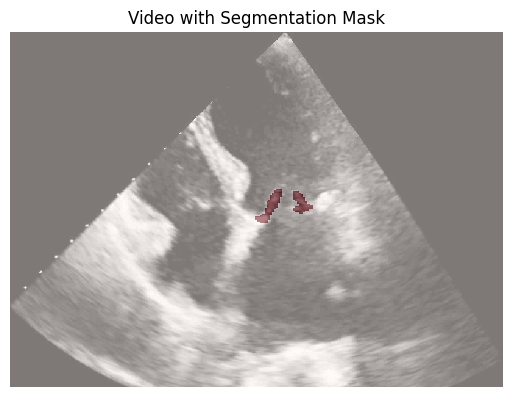

In [ ]:

refined_video_masks = []
num_frames = predicted_masks[test_data[5]["name"]].shape[2]
for frame_idx in range(num_frames):
    # Process each frame individually
    refined_mask = postprocess_segmentation(
        test_data[5]["video"][:, :, frame_idx], predicted_masks[test_data[5]["name"]][:, :, frame_idx], refine_method='grabcut', iterations=10
    )
    refined_video_masks.append(refined_mask)

# Combine processed frames back into a video format
refined_video_masks = np.stack(refined_video_masks, axis=-1)


# Visualize the video with refined masks
play_video_with_mask(
    test_data[5]["video"],  # Original video
    refined_video_masks,  # Refined masks
    output_file=f"animation_5postprocessed.gif",  # Save as GIF
    fps=15
)
